In [2]:
%pip install -q python-dotenv langchain-openai

Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
from langchain_openai import ChatOpenAI

query = '인프런에는 어떤 강의들이 있나요?'

llm = ChatOpenAI(model='gpt-4o-mini')
llm.invoke(query)

AIMessage(content='인프런은 다양한 주제를 다루는 온라인 교육 플랫폼으로, 프로그래밍, 데이터 사이언스, 웹 개발, 모바일 앱 개발, 디자인, IT 자격증, 클라우드 컴퓨팅 등 여러 분야의 강의를 제공합니다. 구체적인 강의 내용은 시간이 지남에 따라 업데이트되므로, 인프런 웹사이트를 방문하여 최신 강의를 확인하는 것이 좋습니다. \n\n일반적으로 인프런에서는 다음과 같은 강의를 찾을 수 있습니다:\n\n1. **프로그래밍 언어 강의**: Python, Java, JavaScript, C++, Ruby 등\n2. **웹 개발 강의**: HTML, CSS, React, Vue.js, Node.js 관련 강의\n3. **데이터 사이언스 및 머신러닝**: 데이터 분석, 머신러닝, 딥러닝, TensorFlow, Pandas 등\n4. **모바일 개발**: Android, iOS, Flutter 등\n5. **디자인**: UI/UX 디자인, 그래픽 디자인, Figma, Adobe 제품 관련 강의\n6. **클라우드 및 DevOps**: AWS, Azure, Docker, Kubernetes 관련 강의\n7. **자격증 준비**: IT 자격증 관련 강의\n\n각 강의는 강사의 설명, 실습 과제, 강의 자료 등이 포함되어 있으며, 무료 강의와 유료 강의가 혼합되어 있습니다. 필요한 강의를 찾기 위해 검색 필터를 활용하는 것도 유용합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 317, 'prompt_tokens': 18, 'total_tokens': 335, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_d

In [5]:
# State, Node, Edge, Conditional Edge 

%pip install -q langgraph

Note: you may need to restart the kernel to use updated packages.


In [11]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]



In [12]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [13]:
def generate(state: AgentState) -> AgentState:
    message = state['messages']
    ai_message = llm.invoke(message)
    return {'messages':[ai_message]}

In [14]:
from langgraph.graph import START, END
graph_builder.add_node('generate', generate)
graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [15]:
graph = graph_builder.compile()

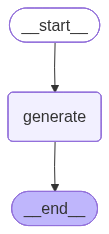

In [18]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
from langchain_core.messages import HumanMessage    

initial_state = {'messages':[HumanMessage(content=query)]}
graph.invoke(initial_state)

{'messages': [AIMessage(content='인프런(In프런)은 다양한 주제의 온라인 강의를 제공하는 플랫폼입니다. 주로 IT, 프로그래밍, 데이터 사이언스, 디자인, 마케팅, 비즈니스 관련 강의를 찾을 수 있습니다. 예를 들어, 다음과 같은 종류의 강의를 제공합니다:\n\n1. **프로그래밍 언어**: Python, Java, JavaScript, C#, Ruby 등\n2. **웹 개발**: HTML, CSS, React, Node.js, Django 등\n3. **모바일 개발**: iOS, Android, Flutter 등\n4. **데이터 사이언스**: 머신러닝, 데이터 분석, 통계 등\n5. **디자인**: UI/UX 디자인, Photoshop, Illustrator 등\n6. **클라우드 및 서버**: AWS, Azure, Docker, Kubernetes 등\n7. **마케팅**: 디지털 마케팅, SEO, 콘텐츠 마케팅 등\n8. **자기계발**: 시간 관리, 커뮤니케이션 스킬, 리더십 등\n\n이 외에도 다양한 분야의 강의가 있으며, 수강생들이 원하는 주제에 맞춰 강의를 선택할 수 있습니다. 강의는 보통 영상과 함께 자료를 제공하며, 질문과 답변을 통해 학습을 지원하는 경우도 많습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 276, 'prompt_tokens': 18, 'total_tokens': 294, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'o